In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
import statsmodels.api as sm
lowess = sm.nonparametric.lowess

In [5]:
var_indices = ['TA','PR','ROF']
var_dict = {'ECHAM5':['tas','pr','mrro'],
            'HadGEM3':['tas','pr'],
            'd4PDF':['TA','PRECIPI','ROF']}

time_window_dict = {'ECHAM5':('1979','2018'),
                    'HadGEM3':('1961','2013'),
                    'd4PDF':('1951','2020')}

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

season_titles = {'winter':'Winter','spring':'Spring','summer':'Summer','autumn':'Autumn'}

input_dir = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/'


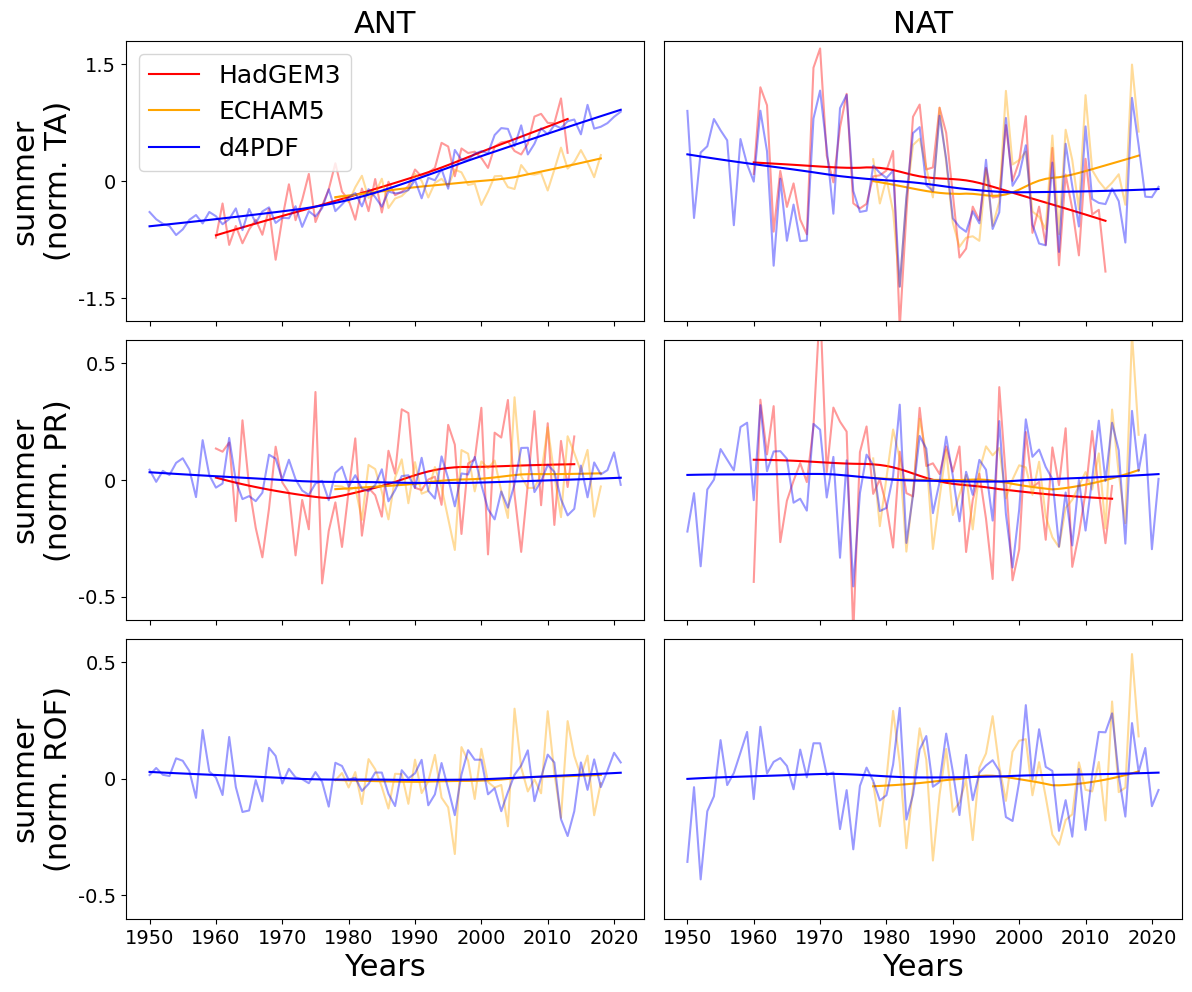

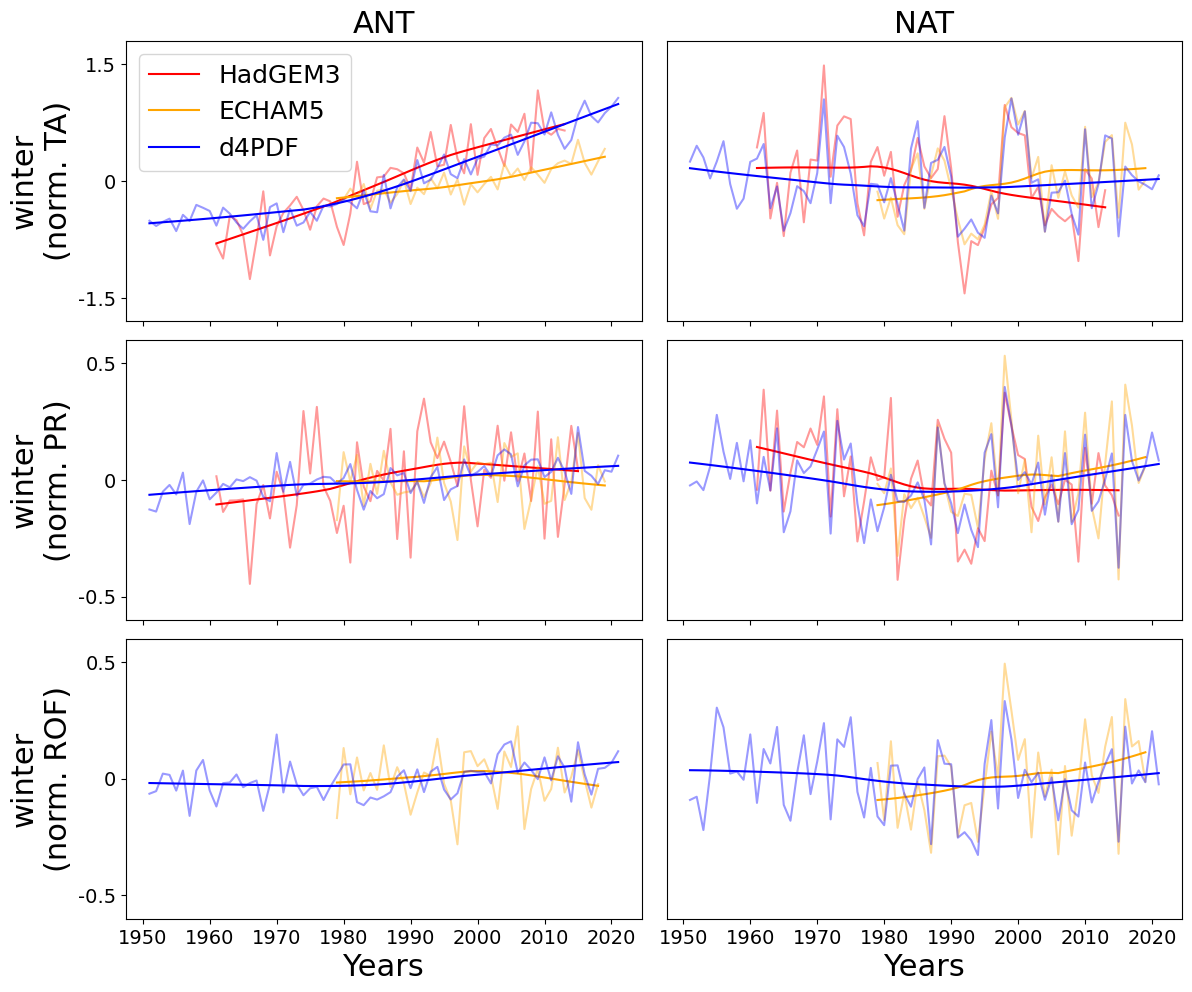

In [8]:
'''
TEMP national average ANT and NAT timeseries
'''

colors = ['red','orange','blue']
scens = ['ANT','NAT']

for season in ['summer','winter']:
    fig,axs = plt.subplots(3,2,figsize=(12,10),sharex=True)
    
    for i in range(3): 

        for model_i,model in enumerate(['HadGEM3','ECHAM5','d4PDF']):

            if i == 2 and model == 'HadGEM3':
                continue

            var = var_dict[model][i]

            all_da = xr.open_dataarray(input_dir+model+'/gaussian/'+var+'/seasonal/means/'+model+'_all_'+season+'_'+var+'_gaussian_'+'ensMean'+'.nc')
            nat_da = xr.open_dataarray(input_dir+model+'/gaussian/'+var+'/seasonal/means/'+model+'_nat_'+season+'_'+var+'_gaussian_'+'ensMean'+'.nc')
            ant_da = all_da - nat_da

            for j,da in enumerate([ant_da,nat_da]):

                y = da.mean(['lat','lon']).values
                x = da.time.dt.year.values
                result = stats.linregress(x, y)
                #regression_line = [result.slope * i + result.intercept for i in x]

                axs[i][j].plot(x,y,c=colors[model_i],alpha=0.4)
                #axs[i][j].plot(x,regression_line,c=colors[model_i],label=model)
                axs[i][j].plot(x,lowess(y,x,return_sorted=False), '-', label=model,c=colors[model_i])


    for i in range(len(axs)):
        for j in range(len(axs[i])):
            if i == 0:
                axs[i][j].set_ylim(-1.8,1.8)
                if j == 0:
                    axs[i][j].set_ylabel(f'{season}\n(norm. {var_indices[i]})',fontdict=font)
                    font['size']=14
                    axs[i][j].set_yticks([-1.5,0,1.5])
                    axs[i][j].set_yticklabels(['-1.5','0','1.5'],fontdict=font)
                    font['size']=22
                else:
                    axs[i][j].set_ylabel('')
                    axs[i][j].set_yticks([])
            else:
                axs[i][j].set_ylim(-0.6,0.6)
                if j == 0:
                    axs[i][j].set_ylabel(f'{season}\n(norm. {var_indices[i]})',fontdict=font)
                    font['size']=14
                    axs[i][j].set_yticks([-0.5,0,0.5])
                    axs[i][j].set_yticklabels(['-0.5','0','0.5'],fontdict=font)
                    font['size']=22
                else:
                    axs[i][j].set_ylabel('')
                    axs[i][j].set_yticks([])


            if i == 2:
                axs[i][j].set_xlabel('Years',fontdict=font)
                font['size']=14
                axs[i][j].set_xticks([1950+10*i for i in range(8)])
                axs[i][j].set_xticklabels([str(1950+10*i) for i in range(8)],fontdict=font)
                font['size']=22

    axs[0][0].set_title('ANT',fontdict=font)
    axs[0][1].set_title('NAT',fontdict=font)
    axs[0][0].legend(loc='upper left',fontsize=18)

    plt.tight_layout(pad=1)
    fig.patch.set_alpha(1)

    #plt.savefig(f'/home/queenle/hydro_attribution/dissertation/figures/supplemental_material/{season}_signal_ts_full_periods.png',dpi=300)


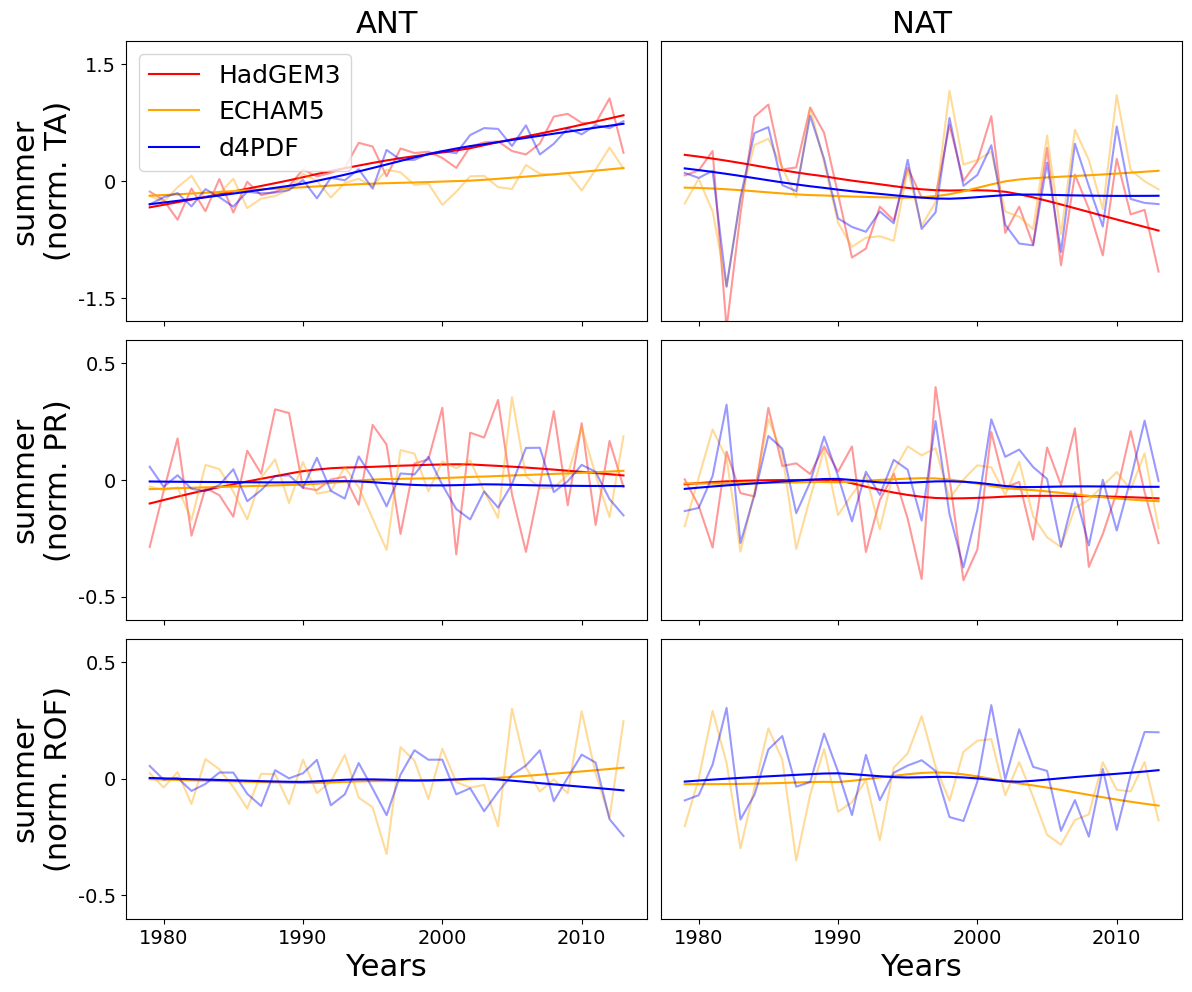

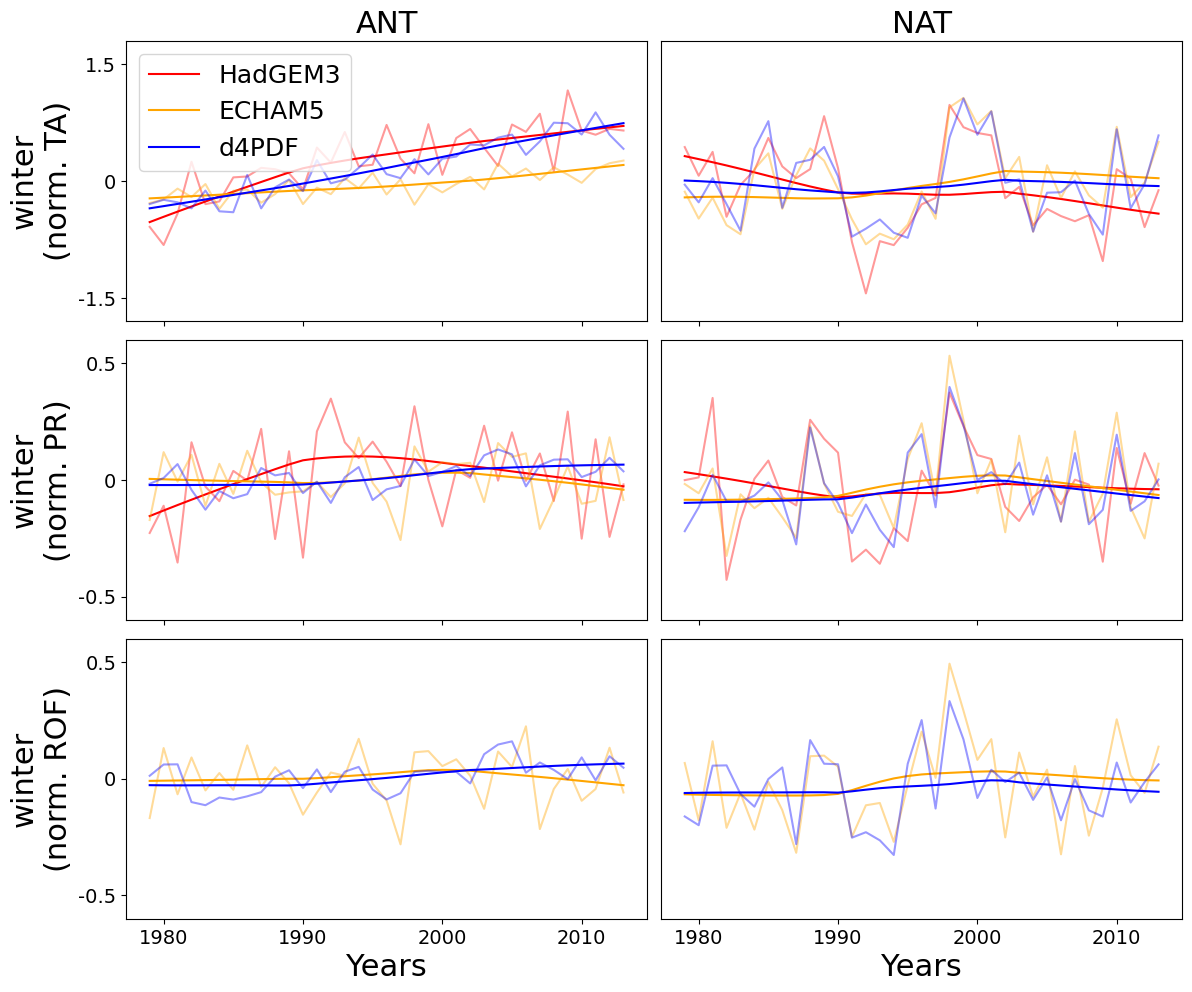

In [9]:
'''
TEMP national average ANT and NAT timeseries
'''

colors = ['red','orange','blue']
scens = ['ANT','NAT']

for season in ['summer','winter']:
    fig,axs = plt.subplots(3,2,figsize=(12,10),sharex=True)
    
    for i in range(3): 

        for model_i,model in enumerate(['HadGEM3','ECHAM5','d4PDF']):

            if i == 2 and model == 'HadGEM3':
                continue

            var = var_dict[model][i]

            all_da = xr.open_dataarray(input_dir+model+'/gaussian/'+var+'/seasonal/means/'+model+'_all_'+season+'_'+var+'_gaussian_'+'ensMean'+'.nc').sel(time=slice('1979','2013'))
            nat_da = xr.open_dataarray(input_dir+model+'/gaussian/'+var+'/seasonal/means/'+model+'_nat_'+season+'_'+var+'_gaussian_'+'ensMean'+'.nc').sel(time=slice('1979','2013'))
            ant_da = all_da - nat_da

            for j,da in enumerate([ant_da,nat_da]):

                y = da.mean(['lat','lon']).values
                x = da.time.dt.year.values
                result = stats.linregress(x, y)
                #regression_line = [result.slope * i + result.intercept for i in x]

                axs[i][j].plot(x,y,c=colors[model_i],alpha=0.4)
                #axs[i][j].plot(x,regression_line,c=colors[model_i],label=model)
                axs[i][j].plot(x,lowess(y,x,return_sorted=False), '-', label=model,c=colors[model_i])


    for i in range(len(axs)):
        for j in range(len(axs[i])):
            if i == 0:
                axs[i][j].set_ylim(-1.8,1.8)
                if j == 0:
                    axs[i][j].set_ylabel(f'{season}\n(norm. {var_indices[i]})',fontdict=font)
                    font['size']=14
                    axs[i][j].set_yticks([-1.5,0,1.5])
                    axs[i][j].set_yticklabels(['-1.5','0','1.5'],fontdict=font)
                    font['size']=22
                else:
                    axs[i][j].set_ylabel('')
                    axs[i][j].set_yticks([])
            else:
                axs[i][j].set_ylim(-0.6,0.6)
                if j == 0:
                    axs[i][j].set_ylabel(f'{season}\n(norm. {var_indices[i]})',fontdict=font)
                    font['size']=14
                    axs[i][j].set_yticks([-0.5,0,0.5])
                    axs[i][j].set_yticklabels(['-0.5','0','0.5'],fontdict=font)
                    font['size']=22
                else:
                    axs[i][j].set_ylabel('')
                    axs[i][j].set_yticks([])


            if i == 2:
                axs[i][j].set_xlabel('Years',fontdict=font)
                font['size']=14
                axs[i][j].set_xticks([1980+10*i for i in range(4)])
                axs[i][j].set_xticklabels([str(1980+10*i) for i in range(4)],fontdict=font)
                font['size']=22

    axs[0][0].set_title('ANT',fontdict=font)
    axs[0][1].set_title('NAT',fontdict=font)
    axs[0][0].legend(loc='upper left',fontsize=18)

    plt.tight_layout(pad=1)
    fig.patch.set_alpha(1)

    #plt.savefig(f'/home/queenle/hydro_attribution/dissertation/figures/supplemental_material/{season}_signal_ts_shared_periods.png',dpi=300)
